In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("/content/nykaa_120days_dataset.csv")

In [4]:
!pip install ydata-profiling


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 5.9 MB/s eta 0:00:00


In [5]:
from ydata_profiling import ProfileReport

prof = ProfileReport(df)
prof.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:00<00:00, 57.20it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [6]:
#120 days rule defininG
df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'])

df['days_since_last_purchase'] = (
    pd.Timestamp.today() - df['last_purchase_date']
).dt.days

# Business Definition
df['churn'] = df['days_since_last_purchase'].apply(
    lambda x: 1 if x > 120 else 0
)

df['churn'].value_counts()

,count
churn,
1,342
0,158


In [7]:
# Remove date column
df.drop(['last_purchase_date'], axis=1, inplace=True)

# Create average spend per purchase
df['avg_spend_per_purchase'] = df['total_spend'] / df['purchase_count']

In [8]:
le = LabelEncoder()

for col in ['gender', 'city']:
    df[col] = le.fit_transform(df[col])

In [11]:
X = df.drop(['customer_id', 'churn', 'days_since_last_purchase'], axis=1)
y = df['churn']

In [12]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
#random forest
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [14]:
#Finalevaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.58

Classification Report:
               precision    recall  f1-score   support

           0       0.29      0.05      0.09        39
           1       0.60      0.92      0.73        61

    accuracy                           0.58       100
   macro avg       0.44      0.48      0.41       100
weighted avg       0.48      0.58      0.48       100



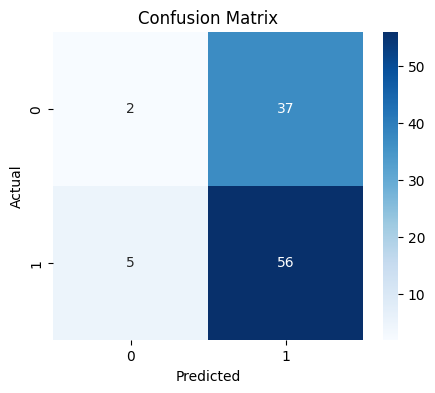

In [15]:
#confusion matrx
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
